In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")

In [3]:
df = pd.read_csv("../data/processed/features.csv")

df.head()

,Date,Open,High,Low,Close,Volume,ticker,RSI,EMA20,EMA50,BBL_20_2.0_2.0,BBM_20_2.0_2.0,BBU_20_2.0_2.0,BBB_20_2.0_2.0,BBP_20_2.0_2.0,volatility_10,future_return,crash
0,2007-11-27 00:00:00+05:30,5729.250000,5743.549805,5655.600098,5698.149902,0,^NSEI,53.122921,5690.085776,5440.556992,5515.624848,5777.994995,6040.365142,9.081702,0.347839,0.022539,0.028114,0
1,2007-11-28 00:00:00+05:30,5699.549805,5749.950195,5595.500000,5617.549805,0,^NSEI,49.532898,5683.177589,5447.497887,5497.368985,5765.434985,6033.500986,9.299073,0.224163,0.017221,0.057401,0
2,2007-11-29 00:00:00+05:30,5617.799805,5725.000000,5612.100098,5634.600098,0,^NSEI,50.298088,5678.551161,5454.835228,5485.920223,5752.132495,6018.344768,9.256124,0.279251,0.017428,0.056810,0
3,2007-11-30 00:00:00+05:30,5633.899902,5782.549805,5632.649902,5762.750000,0,^NSEI,55.730991,5686.570098,5466.910317,5486.125249,5746.947485,6007.769722,9.076896,0.530294,0.019477,0.036710,0
4,2007-12-03 00:00:00+05:30,5765.450195,5878.799805,5754.600098,5865.000000,0,^NSEI,59.532011,5703.563422,5482.521678,5491.240708,5743.577490,5995.914272,8.786746,0.740596,0.020491,0.016300,0


In [4]:
print("Dataset shape:", df.shape)

Dataset shape: (58858, 18)


In [5]:
df["crash"].value_counts()

crash
0    49098
1     9760
Name: count, dtype: int64

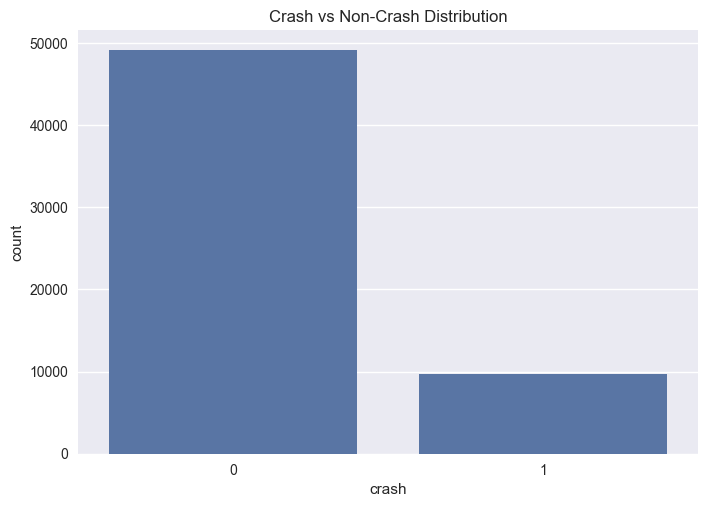

In [6]:
sns.countplot(x="crash", data=df)
plt.title("Crash vs Non-Crash Distribution")
plt.show()

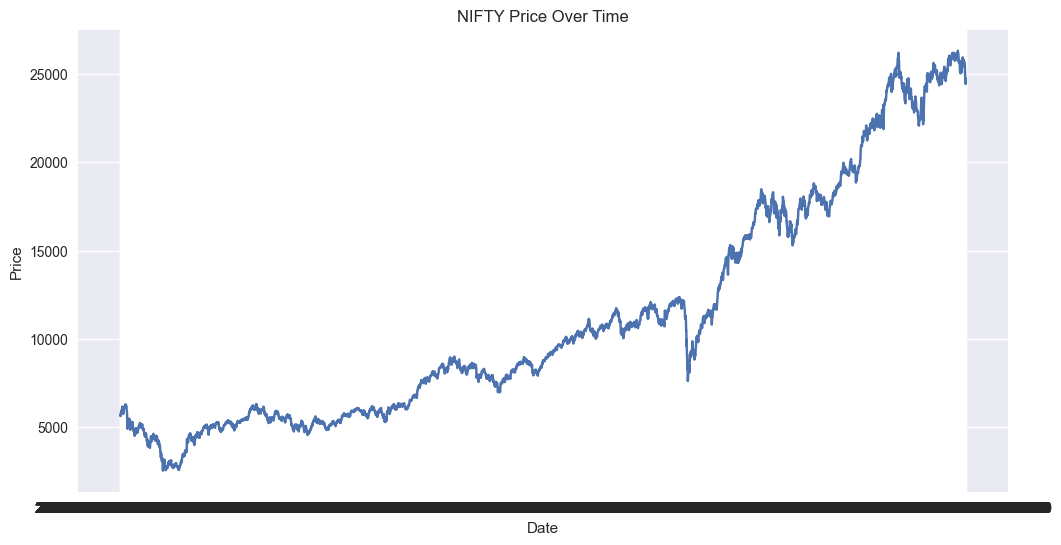

In [7]:
stock = df[df["ticker"] == "^NSEI"]

plt.figure(figsize=(12,6))
plt.plot(stock["Date"], stock["Close"])
plt.title("NIFTY Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

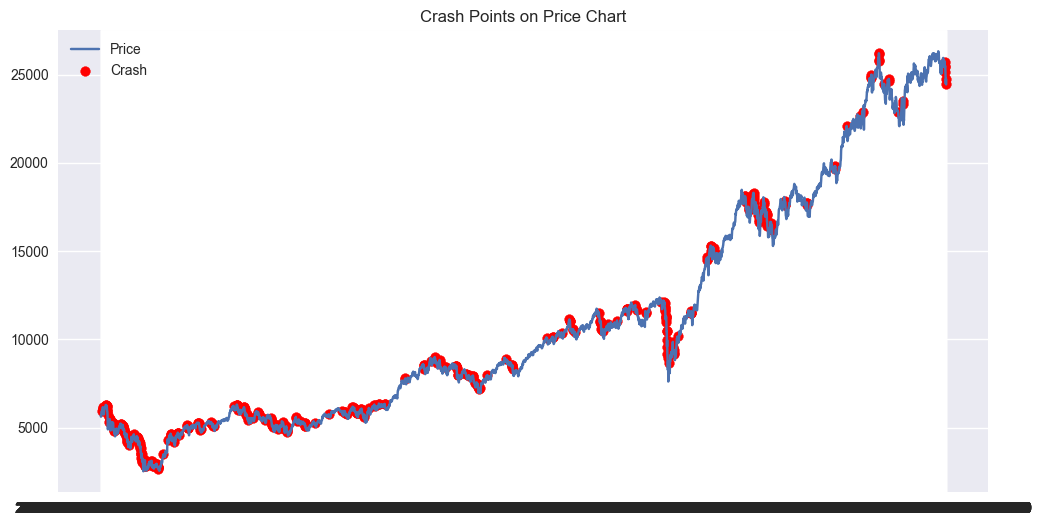

In [8]:
crash_points = stock[stock["crash"] == 1]

plt.figure(figsize=(12,6))

plt.plot(stock["Date"], stock["Close"], label="Price")
plt.scatter(crash_points["Date"], crash_points["Close"], color="red", label="Crash")

plt.title("Crash Points on Price Chart")
plt.legend()
plt.show()

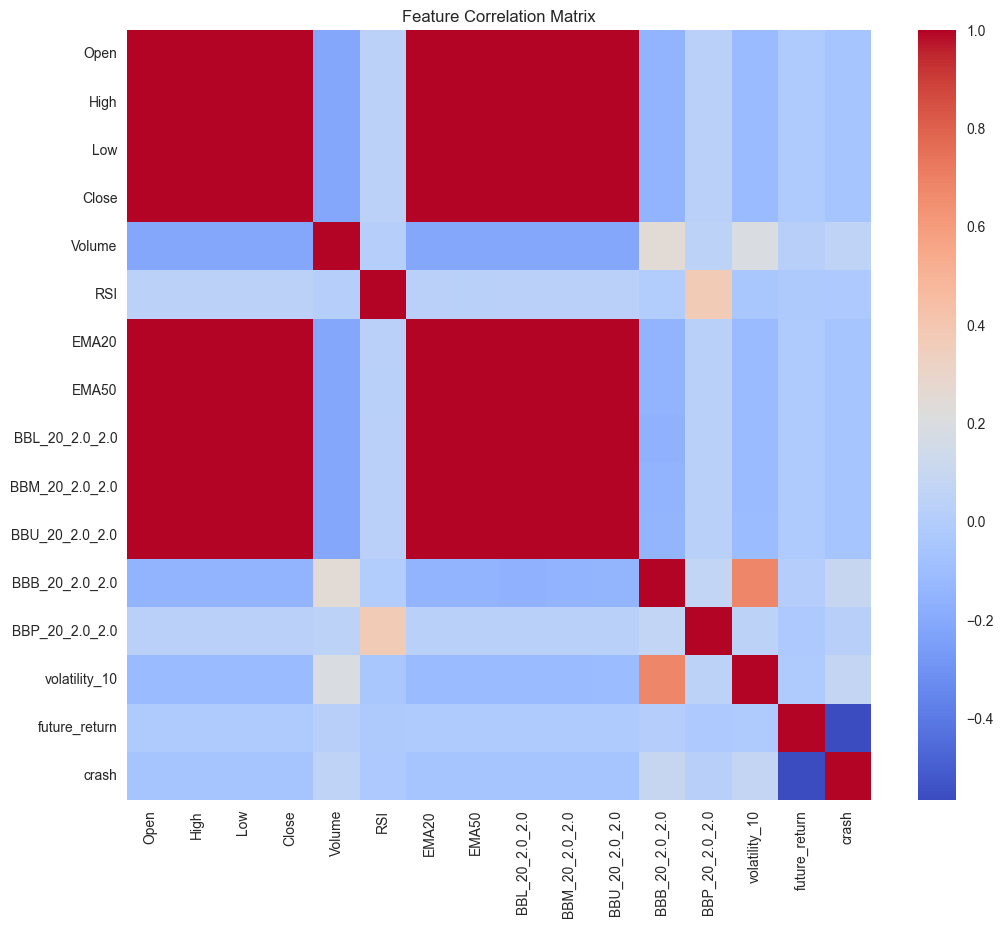

In [9]:
corr = df.select_dtypes(include="number").corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()

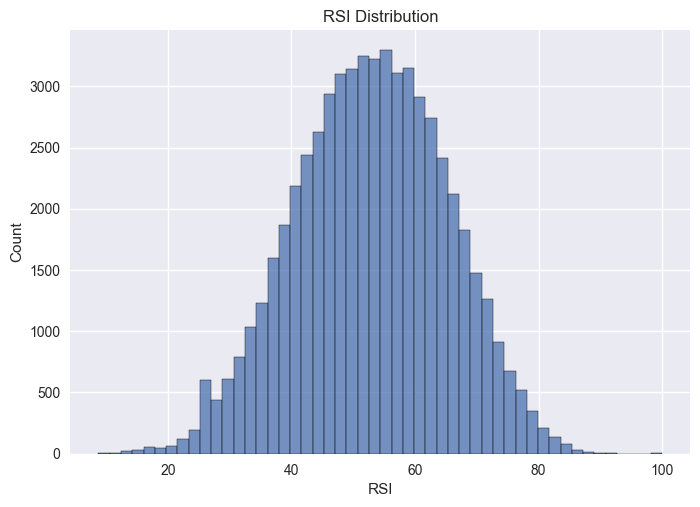

In [10]:
sns.histplot(df["RSI"], bins=50)
plt.title("RSI Distribution")
plt.show()

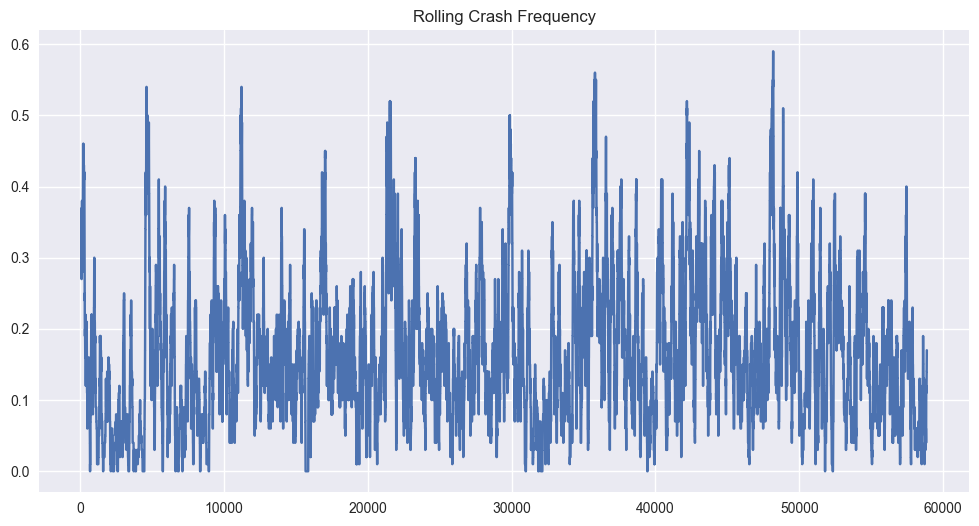

In [11]:
crash_rate = df["crash"].rolling(100).mean()

plt.figure(figsize=(12,6))
plt.plot(crash_rate)
plt.title("Rolling Crash Frequency")
plt.show()

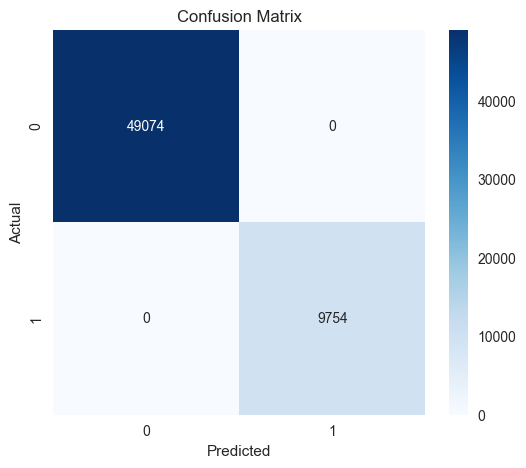

In [13]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

y_true = np.load("../data/processed/y.npy")

# example predictions (replace with real ones if stored)
y_pred = (y_true > 0).astype(int)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

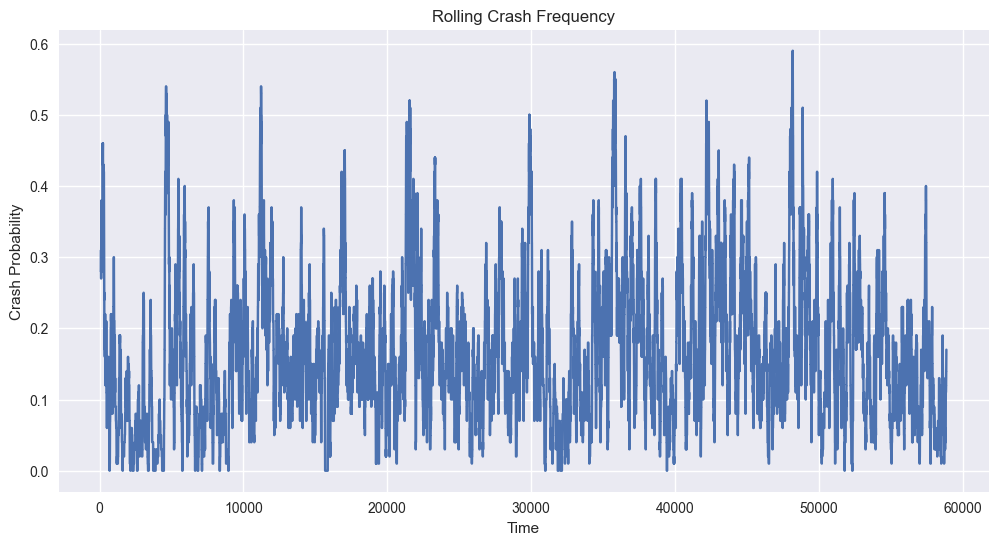

In [14]:
crash_rate = df["crash"].rolling(100).mean()

plt.figure(figsize=(12,6))

plt.plot(crash_rate)

plt.title("Rolling Crash Frequency")
plt.xlabel("Time")
plt.ylabel("Crash Probability")

plt.show()